# Case 1: Temporal Evolution of Acts on Artificial Intelligence

This notebook shows how to query the acts from the Official Journal of the EU that mention Artificial Intelligence over a specific date range. It also demonstrates how to export this data and visualize its temporal evolution.

In [1]:
from bulletin.eurlex.api.client import EurlexBulletinClient

client = EurlexBulletinClient()

date_start = "2017-01-01"
date_end = "2026-04-01"
title_contains = "artificial intelligence"
language = "ENG"

acts_df = client.get_acts(
    date=date_start,
    date_end=date_end,
    title_contains=title_contains,
    language=language,
    output_format="df"
)


Note: you may need to restart the kernel to use updated packages.


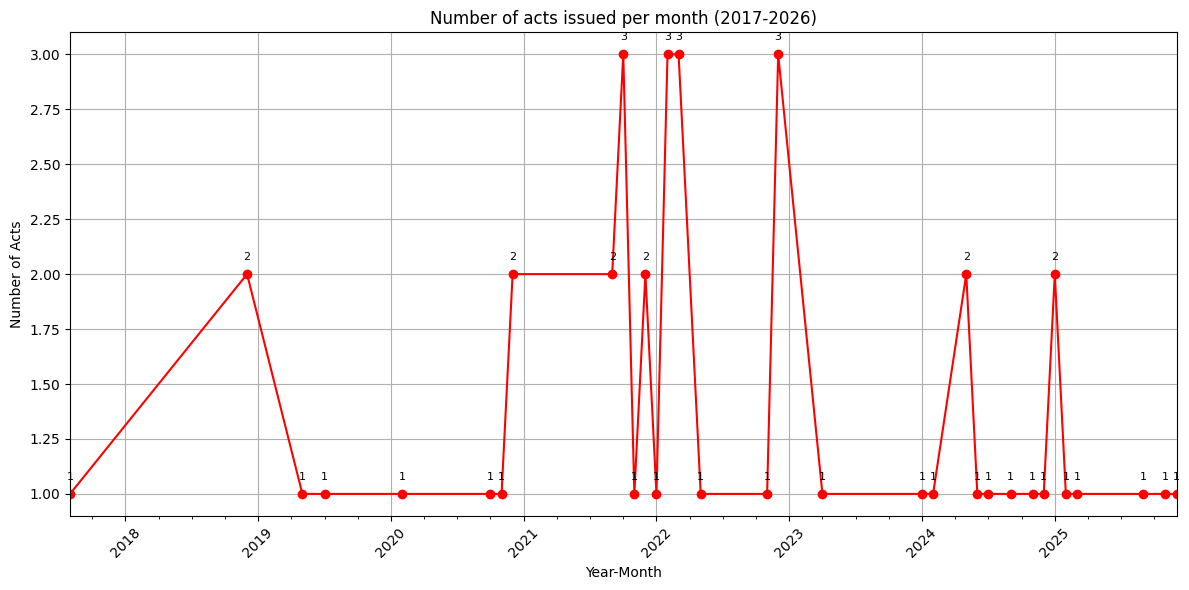

In [2]:
import pandas as pd
%pip install matplotlib
import matplotlib.pyplot as plt

acts_df['date'] = pd.to_datetime(acts_df['date'], errors='coerce')
acts_df['year_month'] = acts_df['date'].dt.to_period('M')
acts_by_month = acts_df.groupby('year_month').size()
plt.figure(figsize=(12, 6))
ax = acts_by_month.plot(kind='line', marker='o', color='red')

for x, y in acts_by_month.items():
    ax.annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)

plt.title("Number of acts issued per month (2017-2026)")
plt.xlabel("Year-Month")
plt.ylabel("Number of Acts")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()